In [1]:
import pandas as pd
import requests
import yfinance as yf
def fetch_data(ticker, start_date = None, end_date = None, interval = "1d"):
    stock = yf.Ticker(ticker)
    ohlcv_df = stock.history(start = start_date, end = end_date, interval = interval)
    ohlcv_df_clean = ohlcv_df.dropna()
    return ohlcv_df_clean

yf_data = fetch_data("WMT", "2025-01-27", "2025-02-06")

def fetch_news_articles(ticker, from_date = None, to_date = None, language = "en", page_size = 100):
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": ticker,
        "apiKey": "6920c0ee94ef49539a8c84af9ed1ea58",
        "language": language,
        "pageSize": page_size,
        "from": from_date,
        "to": to_date,
        "sortBy": "relevancy"
    }
    response = requests.get(url, params = params)
    data = response.json()
    if data.get("status") == "ok":
        articles = data.get("articles", [])
        news_df = pd.DataFrame(articles)[["publishedAt", "title", "description", "url", "content"]]
        news_df["publishedAt"] = pd.to_datetime(news_df["publishedAt"])
        return news_df
    else:
        raise Exception(f"Error fetching news: {data.get('message', 'Unknown error')}")

news_data = fetch_news_articles("WMT", "2025-02-04", "2025-03-03")

In [2]:
yf_df = pd.DataFrame(yf_data)
yf_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-27 00:00:00-05:00,95.900002,97.459999,94.820000,97.400002,18880600,0.0,0.0
2025-01-28 00:00:00-05:00,97.230003,97.839996,96.730003,97.290001,14641600,0.0,0.0
2025-01-29 00:00:00-05:00,97.430000,98.169998,97.220001,97.500000,11261400,0.0,0.0
2025-01-30 00:00:00-05:00,97.690002,98.930000,97.419998,98.650002,11012200,0.0,0.0
2025-01-31 00:00:00-05:00,99.000000,99.000000,97.699997,98.160004,16413900,0.0,0.0


In [3]:
news_df = pd.DataFrame(news_data)
news_df.head()

,publishedAt,title,description,url,content
0,2025-02-11 21:51:58+00:00,"Canned tuna sold at Walmart, Costco, and Trade...","Several brands of canned tuna, sold at Trader ...",https://www.yahoo.com/news/canned-tuna-sold-co...,"Several brands of canned tuna, sold at Trader ..."
1,2025-02-04 21:34:00+00:00,Walmart is trying to make malls happen again,Walmart (WMT) is betting on a mall comeback — ...,https://qz.com/walmart-monroeville-mall-34-mil...,In This Story\r\nWalmart (WMT+1.18%\r\n) is be...
2,2025-02-25 19:03:00+00:00,"Boycott Amazon, Walmart and others for a day, ...","There will be no shopping at Amazon (AMZN), Wa...",https://qz.com/blackout-day-amazon-walmart-fas...,In This Story\r\nThere will be no shopping at ...
3,2025-02-25 17:06:00+00:00,Walmart's bold bet to beat Amazon and win favo...,Walmart (WMT) is betting big it can win over a...,https://qz.com/walmart-donald-trump-amazon-e-c...,In This Story\r\nWalmart (WMT+3.53%\r\n) is be...
4,2025-02-11 21:02:47+00:00,"Canned tuna sold at Costco, Trader Joe's, and ...","Several brands of canned tuna, sold at Trader ...",https://qz.com/canned-tuna-recall-costco-trade...,In This Story\r\nSeveral brands of canned tuna...


In [4]:
import datetime as dt
news_df["publishedAt"] = pd.to_datetime(news_df["publishedAt"]).dt.tz_localize(None)
news_df["publishedAt"] = news_df["publishedAt"].dt.date
yf_df["Date"] = yf_df.index
yf_df["Date"] = pd.to_datetime(yf_df["Date"]).dt.tz_localize(None).dt.date
yf_df.rename(columns = {"Date": "date"}, inplace = True)
merged_df = pd.merge(yf_df, news_df, left_on = "date", right_on = "publishedAt", how = "inner")
merged_df.drop(columns = "publishedAt", inplace = True)
merged_df.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits,date,title,description,url,content
0,99.970001,100.949997,99.690002,100.769997,15201200,0.0,0.0,2025-02-04,Walmart is trying to make malls happen again,Walmart (WMT) is betting on a mall comeback — ...,https://qz.com/walmart-monroeville-mall-34-mil...,In This Story\r\nWalmart (WMT+1.18%\r\n) is be...
1,99.970001,100.949997,99.690002,100.769997,15201200,0.0,0.0,2025-02-04,Walmart and other 'dividend aristocrat' stocks...,"Eric Beiley, Executive Managing Director of St...",https://qz.com/china-tariffs-walmart-sherwin-w...,"Eric Beiley, Executive Managing Director of St..."
2,100.650002,102.580002,100.540001,102.459999,15926700,0.0,0.0,2025-02-05,Amazon Earnings May Signal Strong Year Ahead f...,Amazon will kick off the earnings reporting se...,https://www.investopedia.com/amazon-earnings-c...,Joe Raedle / Getty Images\r\n<ul><li>Amazon wi...
3,100.650002,102.580002,100.540001,102.459999,15926700,0.0,0.0,2025-02-05,Walmart Starts Layoffs,Walmart Inc. (NYSE: WMT) has begun layoffs. Th...,https://biztoc.com/x/b13e07494c33efe2,Walmart Inc. (NYSE: WMT) has begun layoffs. Th...
4,100.650002,102.580002,100.540001,102.459999,15926700,0.0,0.0,2025-02-05,Apparel Stocks To Keep An Eye On – February 03rd,"Costco Wholesale, Berkshire Hathaway, PDD, Wal...",https://www.etfdailynews.com/2025/02/05/appare...,"Costco Wholesale, Berkshire Hathaway, PDD, Wal..."


In [5]:
merged_df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0
date,0
title,0
description,0


In [6]:
merged_df.drop(columns = ["url"], inplace = True)
merged_df = merged_df[["date", "Open", "High", "Low", "Close", "Volume", "title", "description", "content"]]
merged_df.rename(columns = {
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "volume"
}, inplace = True)
merged_df.head()

<ipython-input-6-b2b5cd72b7a7>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df.rename(columns = {


,date,open,high,low,close,volume,title,description,content
0,2025-02-04,99.970001,100.949997,99.690002,100.769997,15201200,Walmart is trying to make malls happen again,Walmart (WMT) is betting on a mall comeback — ...,In This Story\r\nWalmart (WMT+1.18%\r\n) is be...
1,2025-02-04,99.970001,100.949997,99.690002,100.769997,15201200,Walmart and other 'dividend aristocrat' stocks...,"Eric Beiley, Executive Managing Director of St...","Eric Beiley, Executive Managing Director of St..."
2,2025-02-05,100.650002,102.580002,100.540001,102.459999,15926700,Amazon Earnings May Signal Strong Year Ahead f...,Amazon will kick off the earnings reporting se...,Joe Raedle / Getty Images\r\n<ul><li>Amazon wi...
3,2025-02-05,100.650002,102.580002,100.540001,102.459999,15926700,Walmart Starts Layoffs,Walmart Inc. (NYSE: WMT) has begun layoffs. Th...,Walmart Inc. (NYSE: WMT) has begun layoffs. Th...
4,2025-02-05,100.650002,102.580002,100.540001,102.459999,15926700,Apparel Stocks To Keep An Eye On – February 03rd,"Costco Wholesale, Berkshire Hathaway, PDD, Wal...","Costco Wholesale, Berkshire Hathaway, PDD, Wal..."


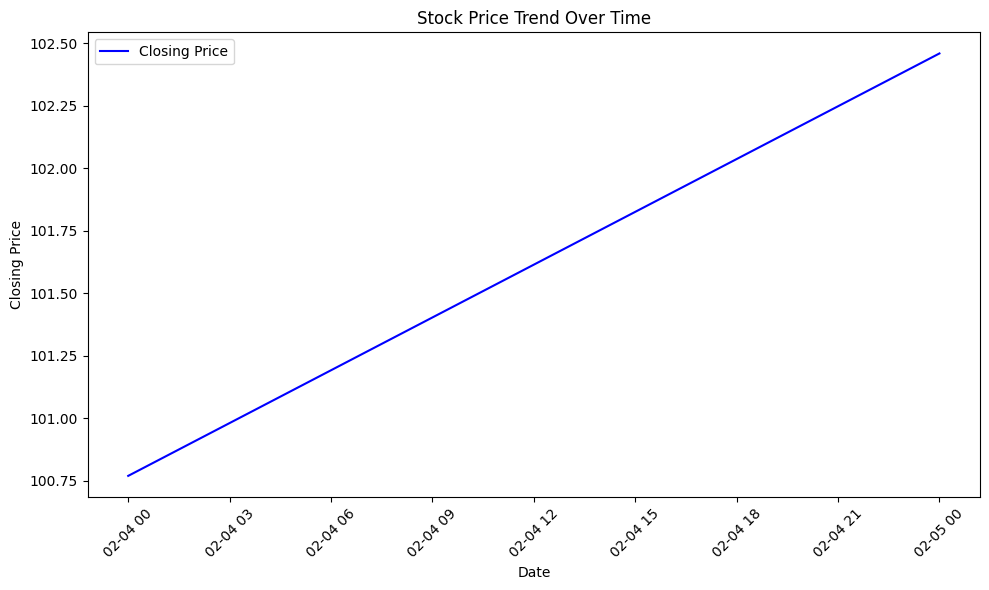

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (10, 6))
plt.plot(merged_df["date"], merged_df["close"], label = "Closing Price", color = "blue")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Stock Price Trend Over Time")
plt.xticks(rotation = 45)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")
analyzer = SentimentIntensityAnalyzer()
def get_sentiment(text):
    sentiment = analyzer.polarity_scores(text)
    return sentiment["compound"]
merged_df["sentiment"] = merged_df["content"].apply(get_sentiment)
merged_df.head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,date,open,high,low,close,volume,title,description,content,sentiment
0,2025-02-04,99.970001,100.949997,99.690002,100.769997,15201200,Walmart is trying to make malls happen again,Walmart (WMT) is betting on a mall comeback — ...,In This Story\r\nWalmart (WMT+1.18%\r\n) is be...,0.0000
1,2025-02-04,99.970001,100.949997,99.690002,100.769997,15201200,Walmart and other 'dividend aristocrat' stocks...,"Eric Beiley, Executive Managing Director of St...","Eric Beiley, Executive Managing Director of St...",0.4019
2,2025-02-05,100.650002,102.580002,100.540001,102.459999,15926700,Amazon Earnings May Signal Strong Year Ahead f...,Amazon will kick off the earnings reporting se...,Joe Raedle / Getty Images\r\n<ul><li>Amazon wi...,0.0000
3,2025-02-05,100.650002,102.580002,100.540001,102.459999,15926700,Walmart Starts Layoffs,Walmart Inc. (NYSE: WMT) has begun layoffs. Th...,Walmart Inc. (NYSE: WMT) has begun layoffs. Th...,0.0000
4,2025-02-05,100.650002,102.580002,100.540001,102.459999,15926700,Apparel Stocks To Keep An Eye On – February 03rd,"Costco Wholesale, Berkshire Hathaway, PDD, Wal...","Costco Wholesale, Berkshire Hathaway, PDD, Wal...",0.0000


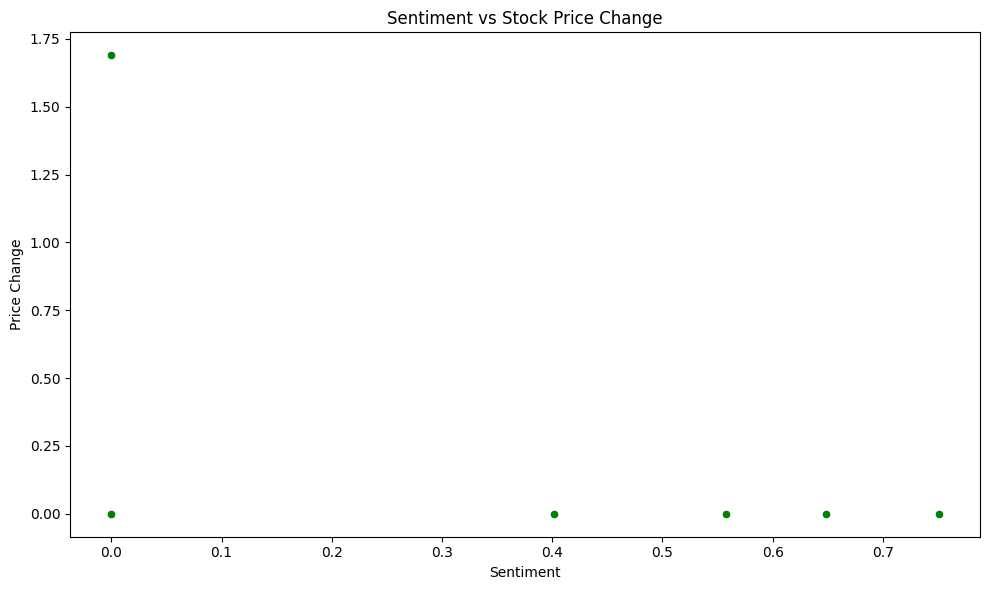

In [15]:
merged_df["price_change"] = merged_df["close"].diff()
plt.figure(figsize = (10, 6))
sns.scatterplot(x = merged_df["sentiment"], y = merged_df["price_change"], color = "green")
plt.xlabel("Sentiment")
plt.ylabel("Price Change")
plt.title("Sentiment vs Stock Price Change")
plt.tight_layout()
plt.show()